In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [71]:
longi = pd.read_csv('oasis_longitudinal.csv')
cross = pd.read_csv('oasis_cross-sectional.csv')


In [60]:
display(longi.head())
display(cross.head())

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [5]:
print("Longi:", longi.shape)
print("Cross:", cross.shape)

Longi: (373, 15)
Cross: (436, 12)


In [6]:
longi.info()


<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    str    
 1   MRI ID      373 non-null    str    
 2   Group       373 non-null    str    
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    str    
 6   Hand        373 non-null    str    
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), str(5)
memory usage: 43.8 KB


In [7]:
cross.info()

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    str    
 1   M/F     436 non-null    str    
 2   Hand    436 non-null    str    
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), str(3)
memory usage: 41.0 KB


In [8]:
"""
¿Desde qué edad es vuelve común la demencia/alzheimer?
¿Qué relaciones existen entre los tamaños craneles y cerebrales con la demencia/alzheimer?
¿Existe una relación entre el nivel socioeconómico y la demencia/alzheimer?
"""

'\n¿Desde qué edad es vuelve común la demencia/alzheimer?\n¿Qué relaciones existen entre los tamaños craneles y cerebrales con la demencia/alzheimer?\n¿Existe una relación entre el nivel socioeconómico y la demencia/alzheimer?\n'

In [80]:
longi.isna().sum()

Subject ID    0
MRI ID        0
Group         0
Visit         0
MR Delay      0
M/F           0
Hand          0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
totWBV        0
totCDR        0
totMMSE       0
dtype: int64

In [79]:
cross.isna().sum()

ID       0
M/F      0
Hand     0
Age      0
Educ     0
SES      0
MMSE     0
CDR      0
eTIV     0
nWBV     0
ASF      0
Delay    0
dtype: int64

In [74]:
longi['SES'] = longi['SES'].fillna(longi['SES'].mean())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
cross['SES'] = cross['SES'].fillna(cross['SES'].mean())
cross['MMSE'] = cross['MMSE'].fillna(cross['MMSE'].median())
cross['Educ'] = cross['Educ'].fillna(cross['Educ'].median())
cross['CDR'] = cross['CDR'].fillna(cross['CDR'].median())
cross['Delay'] = cross['Delay'].fillna(cross['Delay'].median())
"""
He decidido rellenar los valores faltantes de SES y MMSE con la media de cada columna, ya que ambos no tienen una cantidad excesiva de 
valores faltantes. Esto permitirá mantener la integridad del dataset sin eliminar filas completas, lo que resultaría en la pérdida de 
información valiosa para la respuesta de las preguntas ya planteadas.
"""


'\nHe decidido rellenar los valores faltantes de SES y MMSE con la media de cada columna, ya que ambos no tienen una cantidad excesiva de \nvalores faltantes. Esto permitirá mantener la integridad del dataset sin eliminar filas completas, lo que resultaría en la pérdida de \ninformación valiosa para la respuesta de las preguntas ya planteadas.\n'

In [54]:
print("Total de filas duplicadas(longi):", longi.duplicated().sum())
print("Total de filas duplicadas(cross):", cross.duplicated().sum())

Total de filas duplicadas(longi): 0
Total de filas duplicadas(cross): 0


In [13]:
longi.drop_duplicates(inplace=True)
cross.drop_duplicates(inplace=True)

In [14]:
longi.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.104665,3.673329,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


In [15]:
cross.describe()

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,436.000000,235.000000,436.000000,436.000000,235.000000,436.000000,436.000000,436.000000,20.00000
mean,51.357798,3.178723,2.490741,27.063830,0.285106,1481.919725,0.791670,1.198894,20.55000
std,25.269862,1.311510,0.787812,2.711424,0.383405,158.740866,0.059937,0.128682,23.86249
min,18.000000,1.000000,1.000000,14.000000,0.000000,1123.000000,0.644000,0.881000,1.00000
25%,23.000000,2.000000,2.000000,27.063830,0.000000,1367.750000,0.742750,1.111750,2.75000
50%,54.000000,3.000000,2.490741,27.063830,0.000000,1475.500000,0.809000,1.190000,11.00000
75%,74.000000,4.000000,2.490741,29.000000,0.500000,1579.250000,0.842000,1.284250,30.75000
max,96.000000,5.000000,5.000000,30.000000,2.000000,1992.000000,0.893000,1.563000,89.00000


<Figure size 800x500 with 0 Axes>

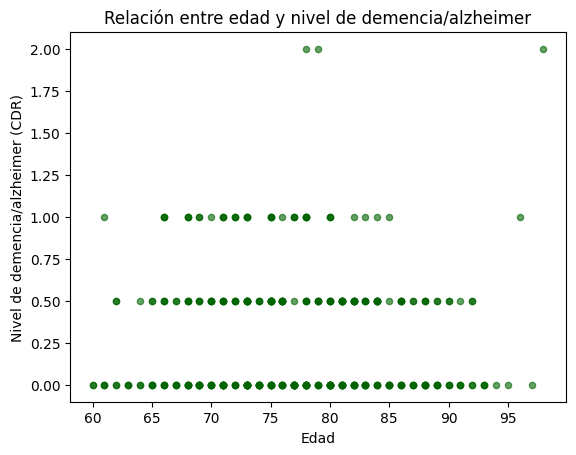

'\nEn este scatter plot podemos observar que no existe una relación clara entre la edad y el nivel de demencia/alzheimer (CDR). \nSin embargo, se puede notar que a partir de los 70 años, hay una mayor concentración de casos con niveles más altos de CDR, \nlo que sugiere que la demencia/alzheimer tiende a ser más común o a empeorar en edades avanzadas.\n'

In [16]:
plt.figure(figsize=(8, 5))
longi.plot(kind='scatter', x='Age', y='CDR', alpha=0.6, 
color='darkgreen')
plt.title('Relación entre edad y nivel de demencia/alzheimer')
plt.xlabel('Edad')
plt.ylabel('Nivel de demencia/alzheimer (CDR)')
plt.show()

"""
En este scatter plot podemos observar que no existe una relación clara entre la edad y el nivel de demencia/alzheimer (CDR). 
Sin embargo, se puede notar que a partir de los 70 años, hay una mayor concentración de casos con niveles más altos de CDR, 
lo que sugiere que la demencia/alzheimer tiende a ser más común o a empeorar en edades avanzadas.
"""

<Figure size 800x500 with 0 Axes>

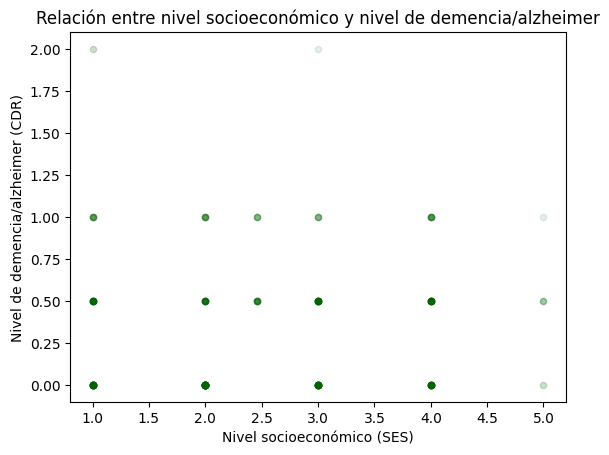

'\nEn este scatter plot podemos observar que no existe una relación clara entre el nivel socioeconómico (SES) y el nivel de demencia/alzheimer (CDR).\n\n'

In [17]:
plt.figure(figsize=(8, 5))
longi.plot(kind='scatter', x='SES', y='CDR', alpha=0.1, 
color='darkgreen')
plt.title('Relación entre nivel socioeconómico y nivel de demencia/alzheimer')
plt.xlabel('Nivel socioeconómico (SES)')
plt.ylabel('Nivel de demencia/alzheimer (CDR)')
plt.show()
"""
En este scatter plot podemos observar que no existe una relación clara entre el nivel socioeconómico (SES) y el nivel de demencia/alzheimer (CDR).

"""

<Figure size 800x500 with 0 Axes>

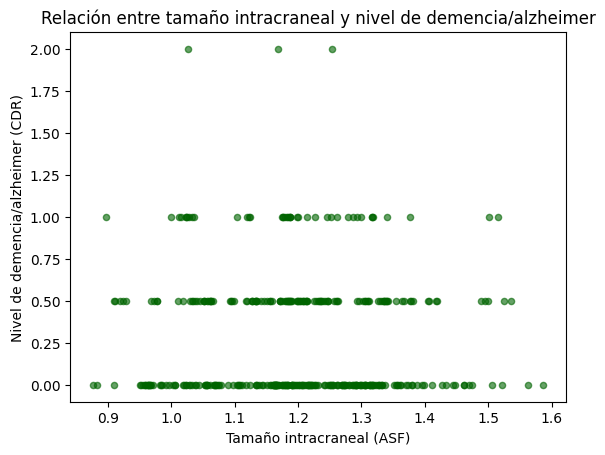

'\nEn este scatter plot podemos observar que no existe una relación clara entre el tamaño intracraneal (ASF) y el nivel de demencia/alzheimer (CDR).\n'

In [18]:
plt.figure(figsize=(8, 5))
longi.plot(kind='scatter', x='ASF', y='CDR', alpha=0.6, 
color='darkgreen')
plt.title('Relación entre tamaño intracraneal y nivel de demencia/alzheimer')
plt.xlabel('Tamaño intracraneal (ASF)')
plt.ylabel('Nivel de demencia/alzheimer (CDR)')
plt.show()

"""
En este scatter plot podemos observar que no existe una relación clara entre el tamaño intracraneal (ASF) y el nivel de demencia/alzheimer (CDR).
"""

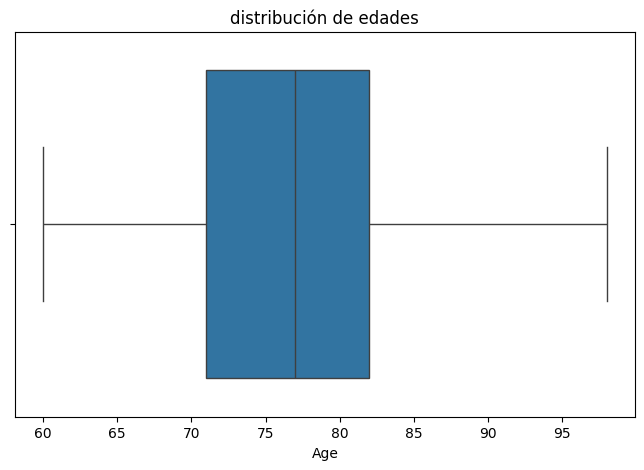

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=longi['Age'])
plt.title('distribución de edades')
plt.show()



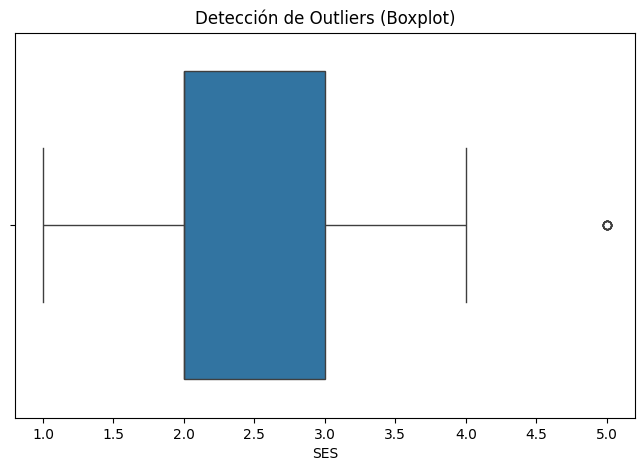

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=longi['SES'])
plt.title('Detección de Outliers (Boxplot)')
plt.show()

Sesgo (Skewness): 1.314006513464738
Curtosis: 2.1594653237620918


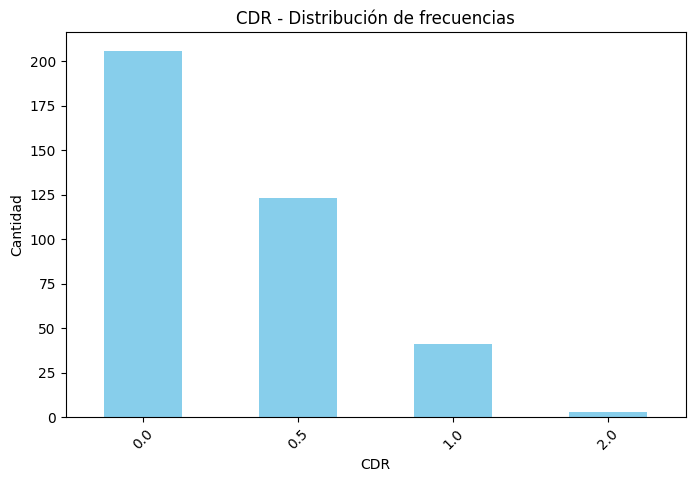

In [21]:
sesgo = stats.skew(longi['CDR'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(longi['CDR'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
# value_counts() cuenta cuántas veces aparece cada categoría
longi['CDR'].value_counts().plot(kind='bar',
color='skyblue')
plt.title('CDR - Distribución de frecuencias')
plt.xlabel('CDR')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) # Rota el texto del eje X si es muy largo
plt.show()

Sesgo (Skewness): 1.3588443536831782
Curtosis: 2.09479778255725


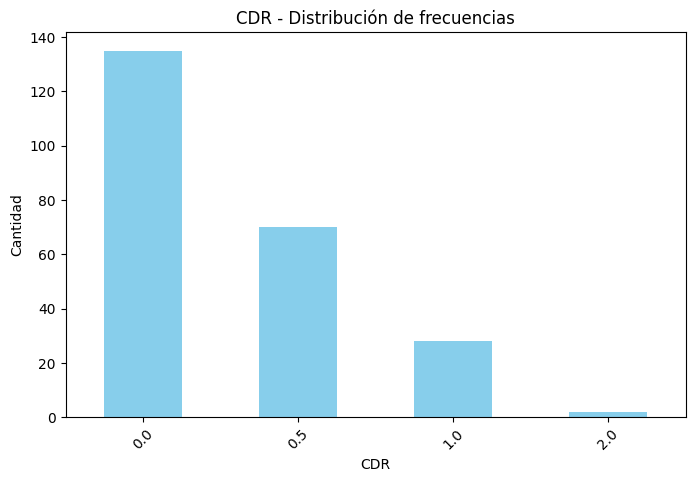

In [22]:
sesgo = stats.skew(cross['CDR'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(cross['CDR'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
# value_counts() cuenta cuántas veces aparece cada categoría
cross['CDR'].value_counts().plot(kind='bar',
color='skyblue')
plt.title('CDR - Distribución de frecuencias')
plt.xlabel('CDR')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) # Rota el texto del eje X si es muy largo
plt.show()

Sesgo (Skewness): -0.5187406215552322
Curtosis: -0.8864706392304624


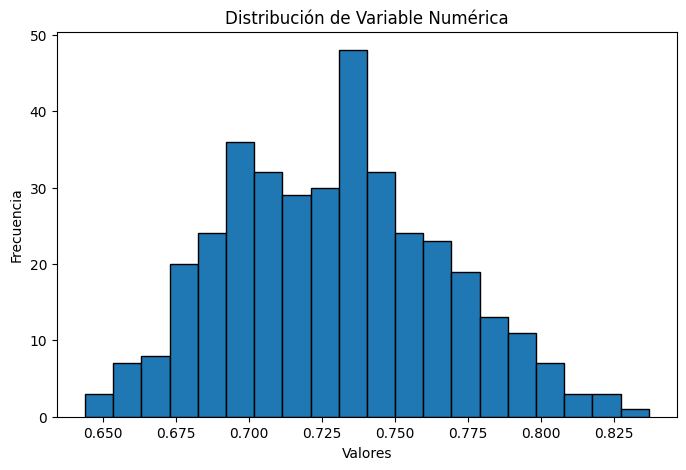

In [23]:
sesgo = stats.skew(cross['nWBV'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(cross['nWBV'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
longi['nWBV'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de Variable Numérica')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

Sesgo (Skewness): 0.23364248614599348
Curtosis: -0.42949106926740477


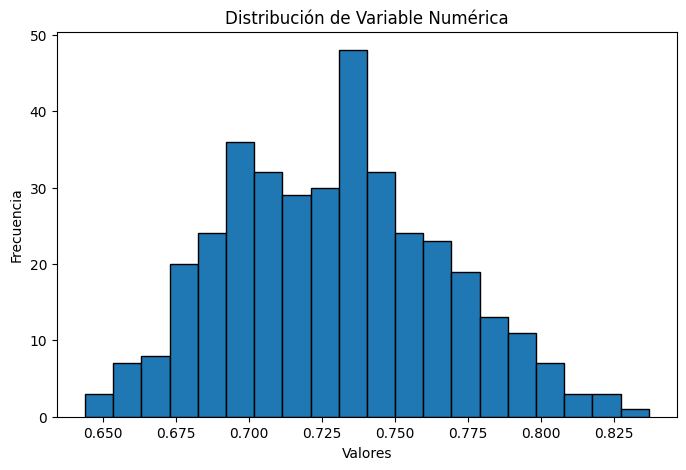

In [75]:
sesgo = stats.skew(longi['nWBV'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(longi['nWBV'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
longi['nWBV'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de Variable Numérica')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

Sesgo (Skewness): -0.25889019899534627
Curtosis: -0.5709590062850181


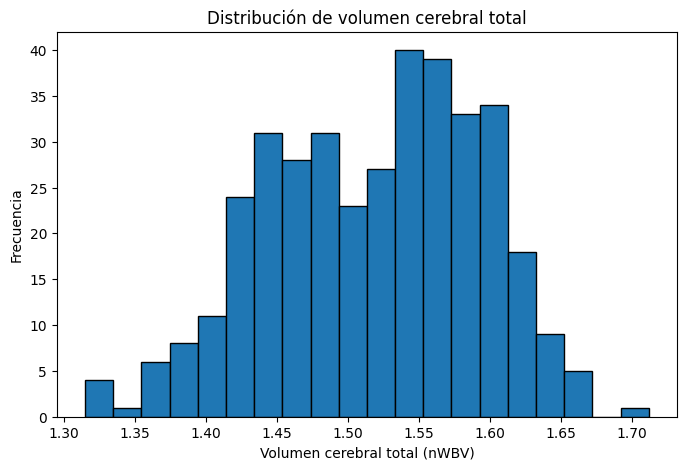

In [76]:
longi['totWBV'] = longi['nWBV'] + cross['nWBV']

sesgo = stats.skew(longi['totWBV'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(longi['totWBV'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
longi['totWBV'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de volumen cerebral total')
plt.xlabel('Volumen cerebral total (nWBV)')
plt.ylabel('Frecuencia')
plt.show()

Sesgo (Skewness): 1.135853914525918
Curtosis: 2.1067163216365925


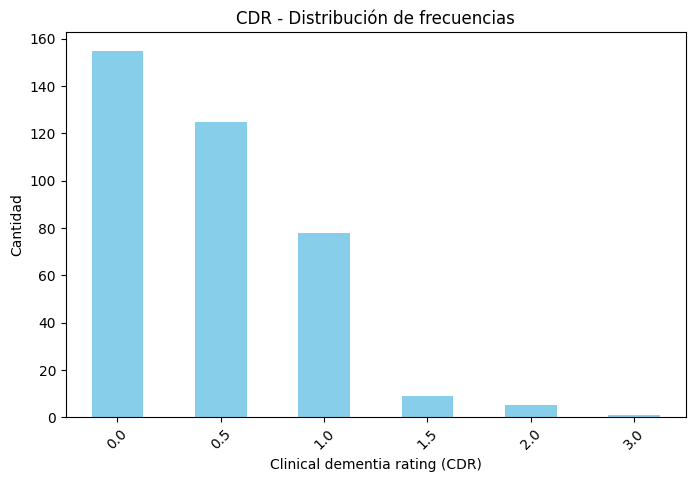

In [86]:
longi['totCDR'] = longi['CDR'] + cross['CDR']

sesgo = stats.skew(longi['totCDR'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(longi['totCDR'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
# value_counts() cuenta cuántas veces aparece cada categoría
longi['totCDR'].value_counts().plot(kind='bar',
color='skyblue')
plt.title('CDR - Distribución de frecuencias')
plt.xlabel('Clinical dementia rating (CDR)')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) # Rota el texto del eje X si es muy largo
plt.show()


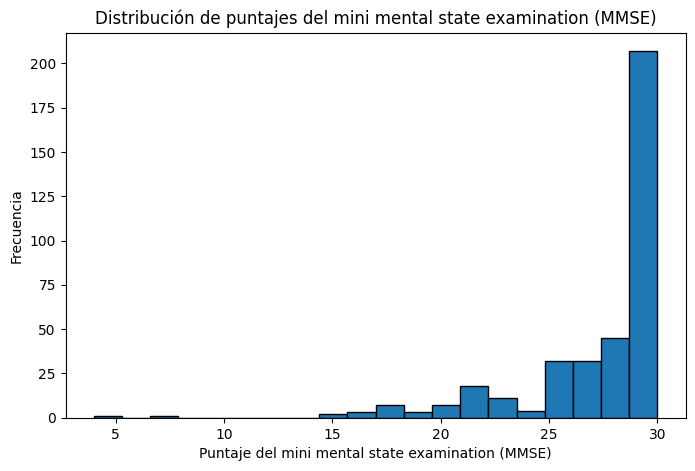

In [83]:
plt.figure(figsize=(8, 5))
longi['MMSE'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de puntajes del mini mental state examination (MMSE)')
plt.xlabel('Puntaje del mini mental state examination (MMSE)')
plt.ylabel('Frecuencia')
plt.show()

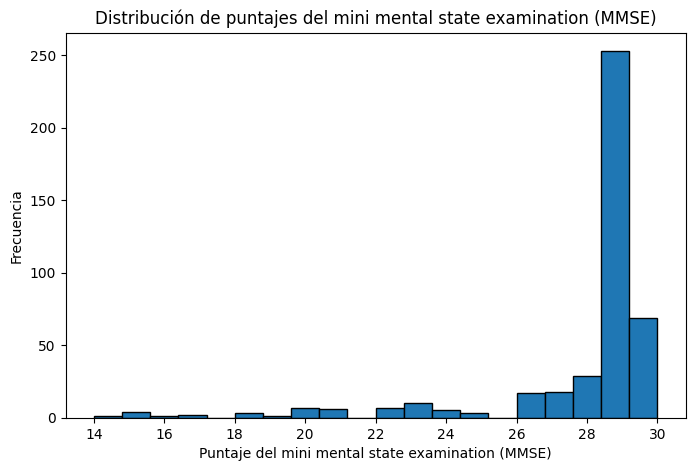

In [84]:
plt.figure(figsize=(8, 5))
cross['MMSE'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de puntajes del mini mental state examination (MMSE)')
plt.xlabel('Puntaje del mini mental state examination (MMSE)')
plt.ylabel('Frecuencia')
plt.show()

Sesgo (Skewness): -1.7072155002003602
Curtosis: 3.6067270396982387


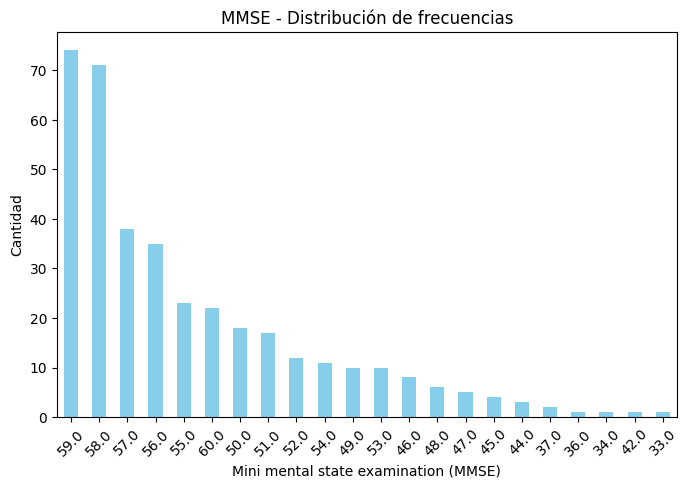

In [95]:
longi['totMMSE'] = longi['MMSE'] + cross['MMSE']

sesgo = stats.skew(longi['totMMSE'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(longi['totMMSE'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
# value_counts() cuenta cuántas veces aparece cada categoría
longi['totMMSE'].value_counts().plot(kind='bar',
color='skyblue')
plt.title('MMSE - Distribución de frecuencias')
plt.xlabel('Mini mental state examination (MMSE)')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) # Rota el texto del eje X si es muy largo
plt.show()


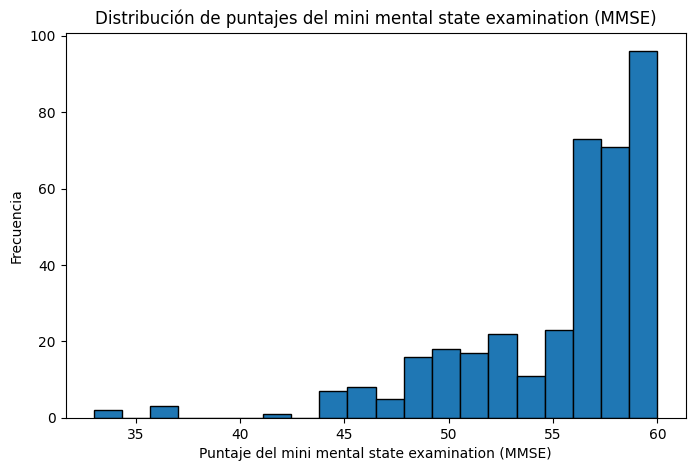

In [97]:
plt.figure(figsize=(8, 5))
longi['totMMSE'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de puntajes del mini mental state examination (MMSE)')
plt.xlabel('Puntaje del mini mental state examination (MMSE)')
plt.ylabel('Frecuencia')
plt.show()

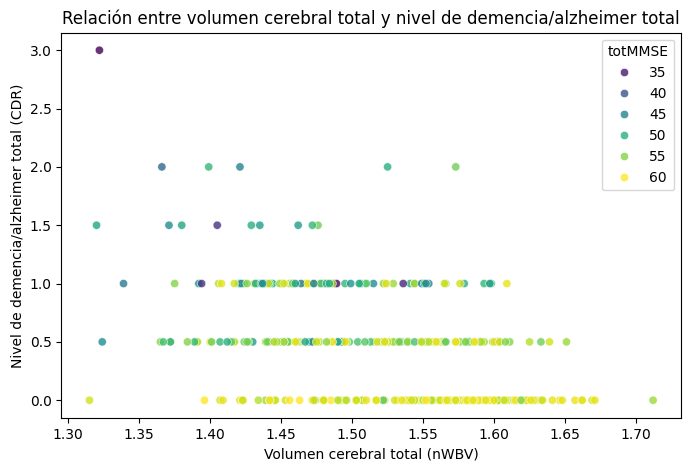

In [96]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=longi, x="totWBV", y="totCDR", hue="totMMSE", palette='viridis', alpha=0.8)
plt.title('Relación entre volumen cerebral total y nivel de demencia/alzheimer total')
plt.xlabel('Volumen cerebral total (nWBV)')
plt.ylabel('Nivel de demencia/alzheimer total (CDR)')
plt.show()



<Figure size 800x500 with 0 Axes>

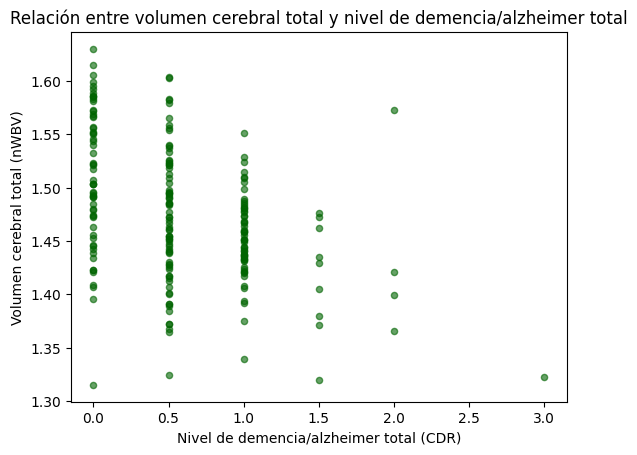

In [28]:
plt.figure(figsize=(8, 5))
longi.plot(kind='scatter', x='totCDR', y='totWBV', alpha=0.6,
color='darkgreen')
plt.title('Relación entre volumen cerebral total y nivel de demencia/alzheimer total')
plt.xlabel('Nivel de demencia/alzheimer total (CDR)')
plt.ylabel('Volumen cerebral total (nWBV)')
plt.show()

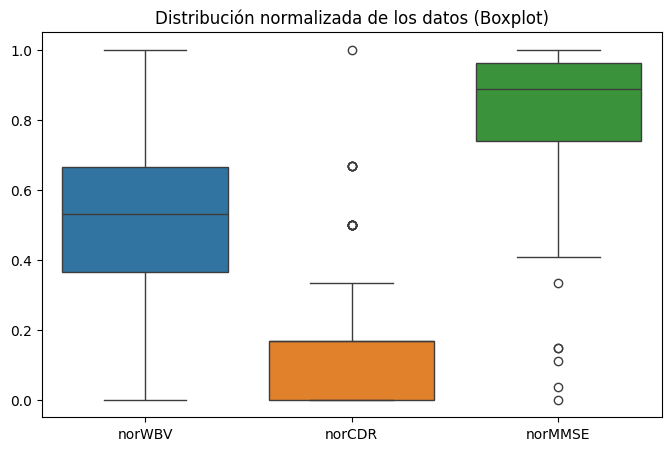

In [93]:
longi['logWBV'] = np.log1p(longi['totWBV'])
longi['logCDR'] = np.log1p(longi['totCDR'])
longi['logMMSE'] = np.log1p(longi['totMMSE'])

minW = longi['totWBV'].min()
maxW = longi['totWBV'].max()
longi['norWBV'] = (longi['totWBV'] - minW) / (maxW
- minW)

minC = longi['totCDR'].min()
maxC = longi['totCDR'].max()
longi['norCDR'] = (longi['totCDR'] - minC) / (maxC
- minC)


minM = longi['totMMSE'].min()
maxM = longi['totMMSE'].max()
longi['norMMSE'] = (longi['totMMSE'] - minM) / (maxM
- minM)

datos = [longi['norWBV'], longi['norCDR'], longi['norMMSE']]

plt.figure(figsize=(8, 5))
sns.boxplot(data=datos)
plt.title('Distribución normalizada de los datos (Boxplot)')
plt.show()

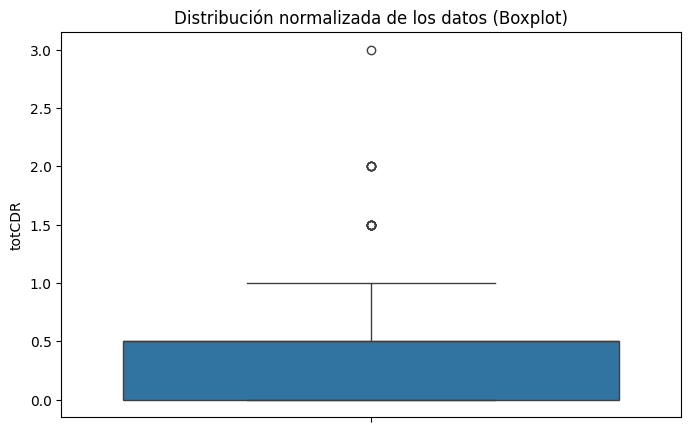

In [94]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=longi['totCDR'])
plt.title('Distribución normalizada de los datos (Boxplot)')
plt.show()